In [1]:
import pandas
import os
import numpy as np

In [2]:
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_caract = []

for year in years:
    df_caract_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"caract-{year}.csv"), encoding="utf-8", sep = ";")
    df_caract.append(df_caract_year)

df_caract = pandas.concat(df_caract)

In [3]:
# Drop ["adr","dep","com"] as we will work in our analysis with latitude and logitude and they contain this info already
df_caract.drop(columns=["adr","dep","com"],inplace=True)
df_caract.drop(columns=["an"],inplace=True) # Also we are not going to use year

In [4]:
df_caract = df_caract.replace(-1, pandas.NA)
df_caract.isna().sum()

Num_Acc       0
jour          0
mois          0
hrmn          0
lum           9
agg           0
int          14
atm          26
col        1619
lat           0
long          0
dtype: int64

In [5]:
df_caract = df_caract.dropna()

In [6]:
column_names_to_int = ["jour", "mois", "lum", "agg", "int", "atm", "col", "lat", "long"]

df_caract[column_names_to_int] = df_caract[column_names_to_int].apply(
    lambda col: pandas.to_numeric(
        col.astype(str).str.extract(r'(-?\d+)')[0],
        errors="coerce"
    )
)

cols_float = ["lat", "long"]
cols_small_int = list(set(column_names_to_int) - set(cols_float))
df_caract[cols_small_int] = df_caract[cols_small_int].astype("int64")
df_caract[cols_float] = df_caract[cols_float].astype("float64")

However, raw coordinates can still be improved slightly. A simple and very effective trick is to convert them into spatial clusters. This lets the model learn “regions with similar accident characteristics”.
A simple way to do this is to cluster coordinates using KMeans.

Now instead of thousands of unique coordinates, you have 50 geographic zones that group nearby accidents.

In [7]:
from sklearn.cluster import KMeans

coords = df_caract[["lat", "long"]]

kmeans = KMeans(n_clusters=50, random_state=42)
df_caract["geo_cluster"] = kmeans.fit_predict(coords)

df_caract.drop(columns=["lat", "long"], inplace=True)

In [8]:
df_caract['day_of_year'] = (df_caract['mois'] - 1) * 30 + df_caract['jour']
df_caract['day_sin'] = np.sin(2 * np.pi * df_caract['day_of_year'] / 365)
df_caract['day_cos'] = np.cos(2 * np.pi * df_caract['day_of_year'] / 365)

df_caract = df_caract.drop(columns=["jour","mois", "day_of_year"])

df_caract["hrmn"] = df_caract["hrmn"].str.replace(":", "", regex=False)
df_caract["hrmn"] = df_caract["hrmn"].astype(int)

df_caract['hour_sin'] = np.sin(2 * np.pi * df_caract['hrmn']/2400)
df_caract['hour_cos'] = np.cos(2 * np.pi * df_caract['hrmn']/2400)

df_caract = df_caract.drop(columns=["hrmn"])

In [9]:
df_caract.columns

Index(['Num_Acc', 'lum', 'agg', 'int', 'atm', 'col', 'geo_cluster', 'day_sin',
       'day_cos', 'hour_sin', 'hour_cos'],
      dtype='str')

In [10]:
features = ['lum', 'agg', 'int', 'atm', 'col', 'geo_cluster',
            'day_sin', 'day_cos', 'hour_sin', 'hour_cos']

categorical_features_caract = [
 'lum',
 'agg',
 'int',
 'atm',
 'col',
 'geo_cluster'
]

numerical_features_caract = ['day_sin', 'day_cos', 'hour_sin', 'hour_cos']

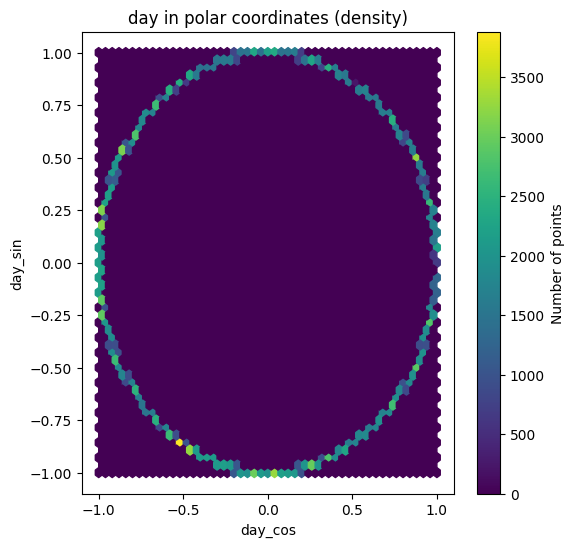

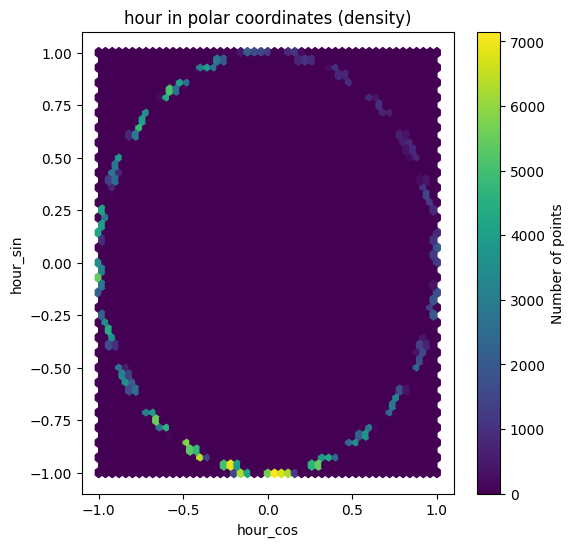

In [11]:
import matplotlib.pyplot as plt

pairs = [('day_cos', 'day_sin'), ('hour_cos', 'hour_sin')]

for x, y in pairs:
    plt.figure(figsize=(6,6))
    plt.hexbin(df_caract[x], df_caract[y], gridsize=50, cmap='viridis')
    plt.colorbar(label='Number of points')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x.split('_')[0]} in polar coordinates (density)")
    plt.show()

In [12]:
df_caract_analyse = df_caract.copy()
df_caract_analyse.columns

Index(['Num_Acc', 'lum', 'agg', 'int', 'atm', 'col', 'geo_cluster', 'day_sin',
       'day_cos', 'hour_sin', 'hour_cos'],
      dtype='str')

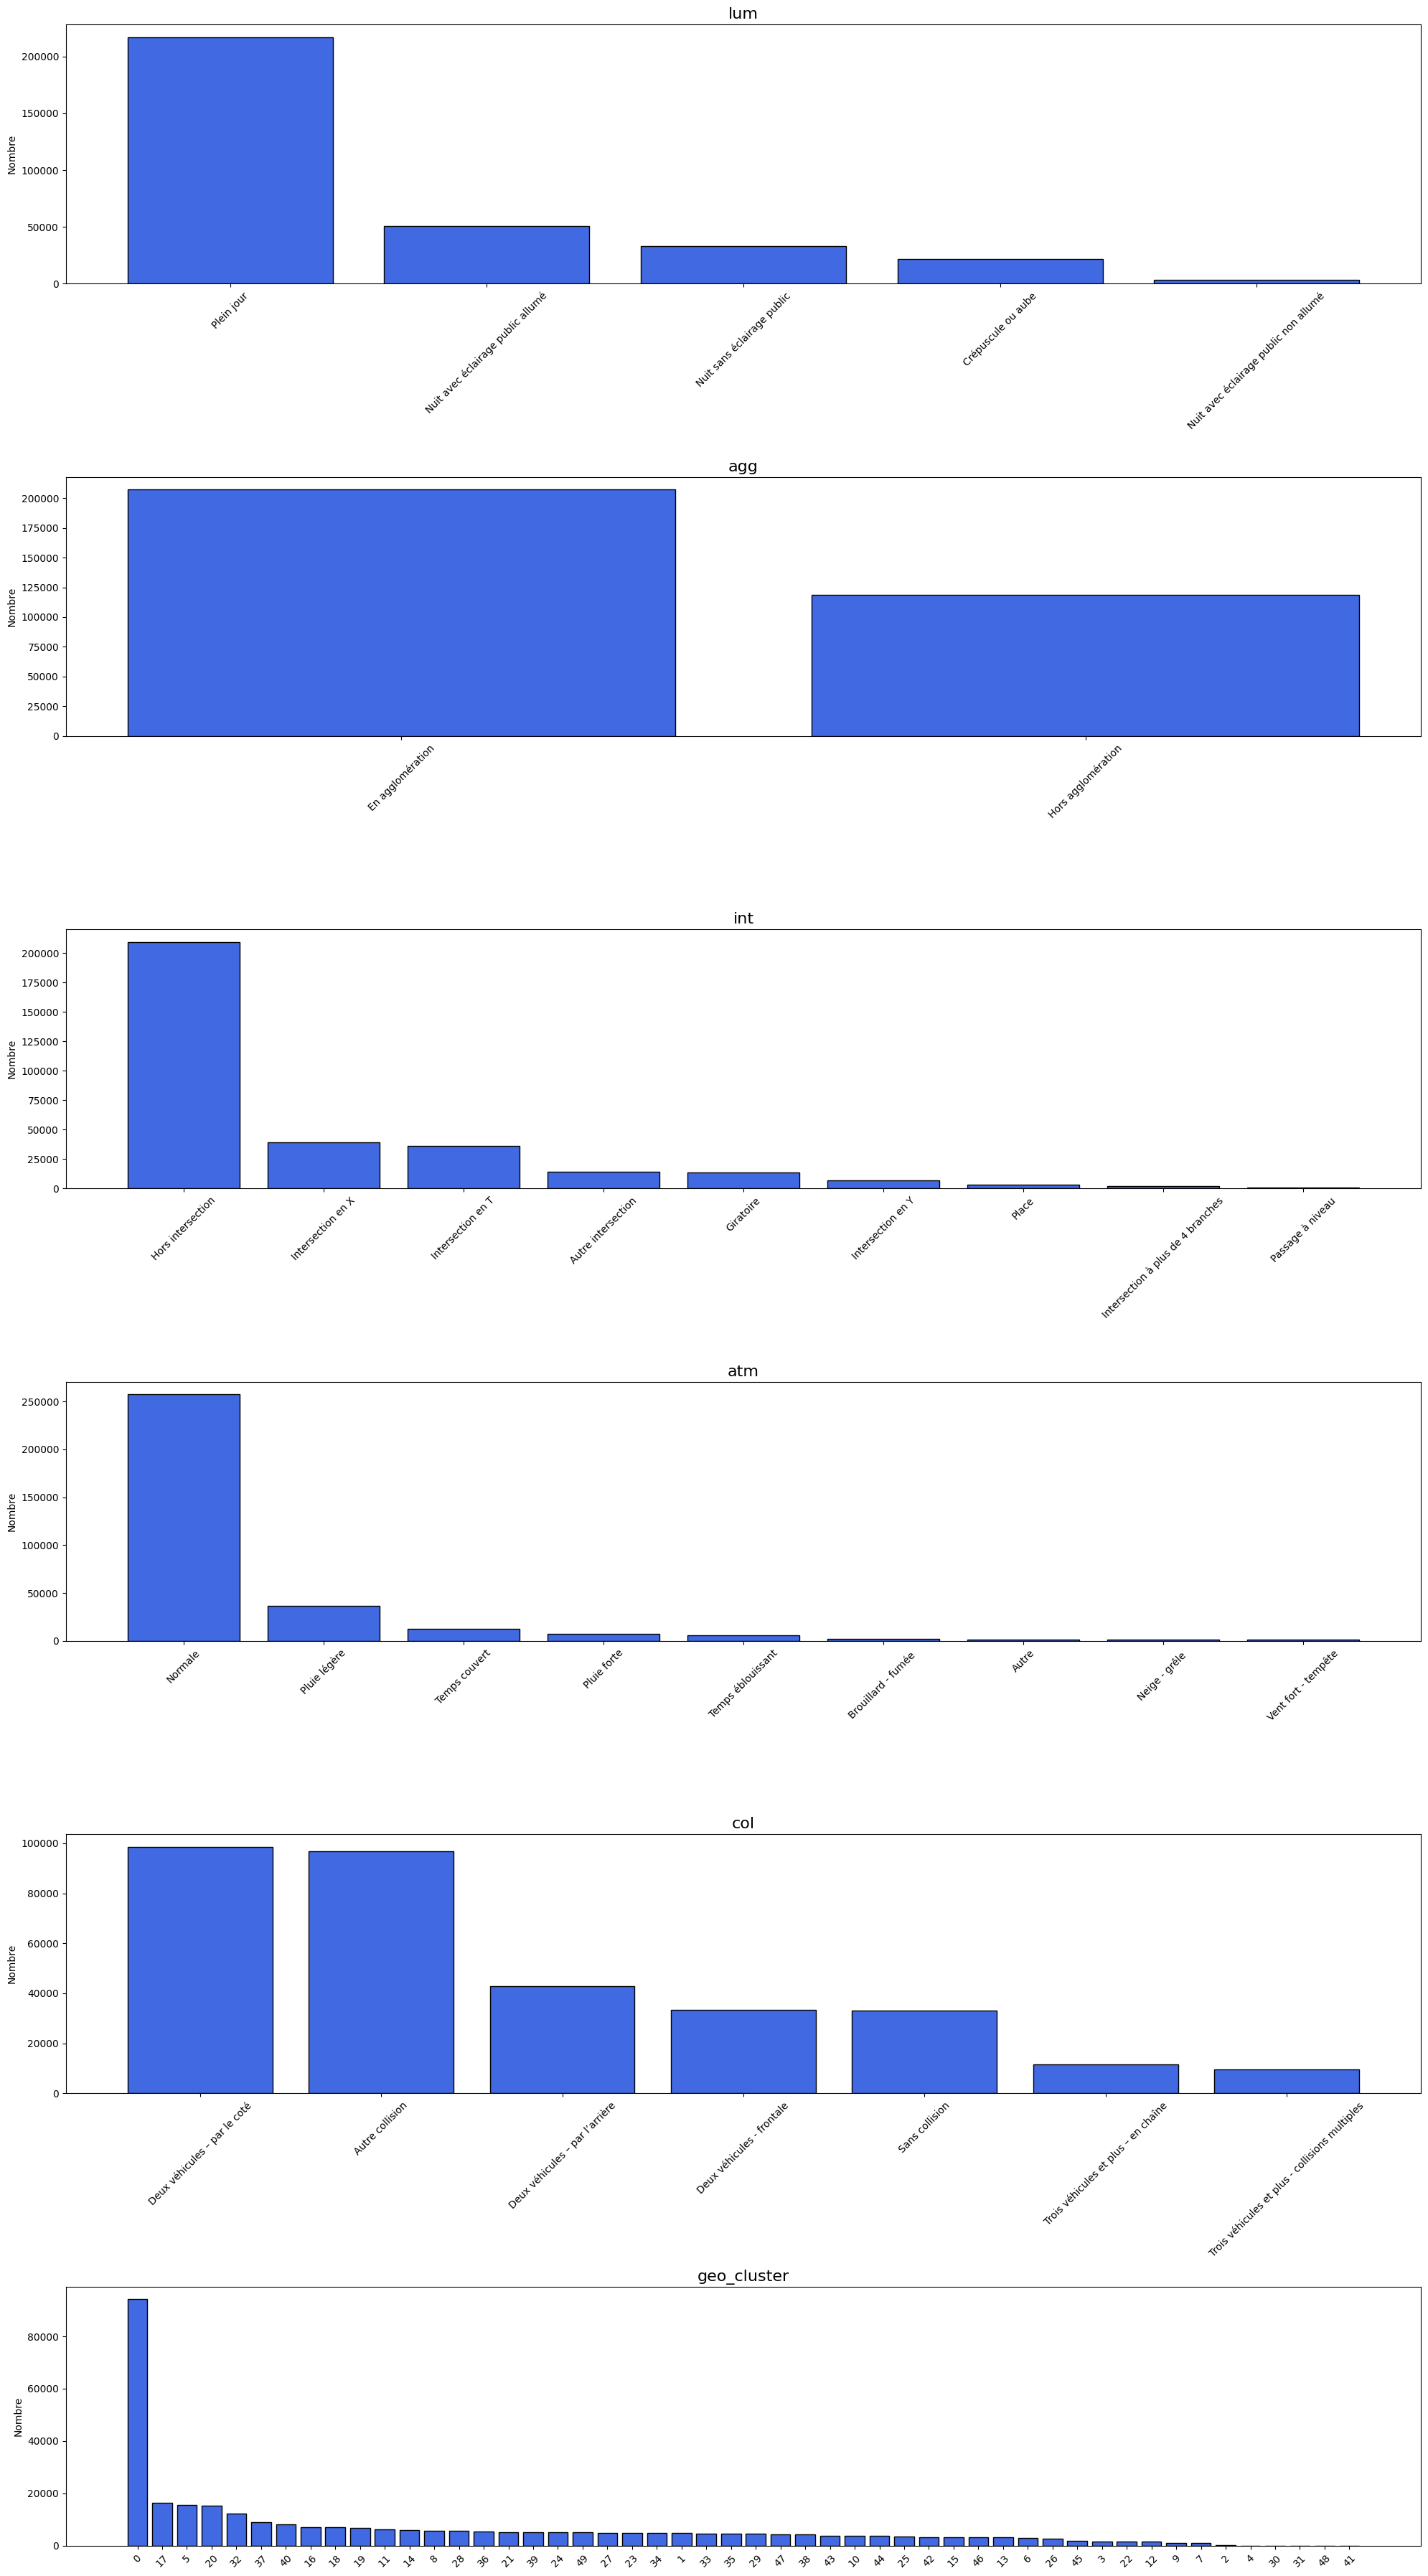

In [13]:
df_caract_analyse = df_caract.copy() 

mapping = {1 : "Plein jour" , 
2 : "Crépuscule ou aube"  ,
3 : "Nuit sans éclairage public"  ,
4 : "Nuit avec éclairage public non allumé"  ,
5 : "Nuit avec éclairage public allumé" }
df_caract_analyse["lum"] = df_caract_analyse["lum"].replace(mapping)

mapping = {1 : "Hors agglomération",
2 : "En agglomération"}
df_caract_analyse["agg"] = df_caract_analyse["agg"].replace(mapping)

mapping = {1 : "Hors intersection" ,
2 : "Intersection en X",
3 : "Intersection en T",  
4 : "Intersection en Y", 
5 : "Intersection à plus de 4 branches", 
6 : "Giratoire" , 
7 : "Place"  ,
8 : "Passage à niveau",  
9 : "Autre intersection"  
}
df_caract_analyse["int"] = df_caract_analyse["int"].replace(mapping)

mapping = {
1 : "Normale"  ,
2 : "Pluie légère"  ,  
3 : "Pluie forte"  ,
4 : "Neige - grêle " , 
5 : "Brouillard - fumée ", 
6 : "Vent fort - tempête",  
7 : "Temps éblouissant",  
8 : "Temps couvert",  
9 : "Autre"}
df_caract_analyse["atm"] = df_caract_analyse["atm"].replace(mapping)

mapping = {
1 : "Deux véhicules - frontale",  
2 : "Deux véhicules – par l’arrière",
3 : "Deux véhicules – par le coté" ,
4 : "Trois véhicules et plus – en chaîne",  
5 : "Trois véhicules et plus - collisions multiples" ,
6 : "Autre collision" ,
7 : "Sans collision" }
df_caract_analyse["col"] = df_caract_analyse["col"].replace(mapping)

fig, ax = plt.subplots(len(categorical_features_caract), 1, figsize=(20, 6*len(categorical_features_caract)))

for i, feature in enumerate(categorical_features_caract):
    values = df_caract_analyse[feature]
    counts = values.value_counts()
    
    ax[i].bar(counts.index.astype(str), counts.values, color="royalblue", edgecolor="black")
    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Nombre")

plt.tight_layout()

Now, we'll see which features are the most useful in prediction of our target class.

In [14]:
# We need to load usagers, because it conatains our target column
df_usagers = pandas.read_csv("df_usagers_clean.csv")

In [15]:
df_caract_with_target = df_caract.merge(
    df_usagers[['Num_Acc', 'grav_bin']],
    on='Num_Acc',
    how='left'
)
target = "grav_bin"

In [16]:
X_num = df_caract_with_target[numerical_features_caract]
X_cat = pandas.get_dummies(df_caract_with_target[categorical_features_caract], drop_first=True)

X = pandas.concat([X_num, X_cat], axis=1)
y = df_caract_with_target[target]

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

importances = pandas.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

day_sin        0.174129
day_cos        0.167446
geo_cluster    0.160300
hour_cos       0.154823
hour_sin       0.154383
col            0.081334
agg            0.032698
atm            0.028535
int            0.027136
lum            0.019217
dtype: float64


In [19]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y)

pandas.Series(mi, index=X.columns).sort_values(ascending=False)

agg            0.110086
atm            0.057842
col            0.048776
lum            0.043614
int            0.042426
geo_cluster    0.030106
hour_cos       0.002556
hour_sin       0.002461
day_sin        0.001521
day_cos        0.000495
dtype: float64

Here we see different results based on different metics, and thus in this case we cannot directly eliminate any features as:

Rule of thumb:
If you are going to use tree-based models, trust RF importances more.
If you are going to use linear/logistic models, you might want to look at MI or correlation because linear models need individually informative features.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    # "Random Forest": RandomForestClassifier(n_estimators=100),
    # "Gradient Boosting": GradientBoostingClassifier(),
    # "LDA": LinearDiscriminantAnalysis(),
    # "QDA": QuadraticDiscriminantAnalysis()
}

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

for name, model in models.items():
    model.fit(X_train, y_train)

In [25]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    
    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


 Logistic Regression
Accuracy: 0.81681266223315
              precision    recall  f1-score   support

           0       0.82      1.00      0.90    119275
           1       0.49      0.02      0.03     26734

    accuracy                           0.82    146009
   macro avg       0.66      0.51      0.46    146009
weighted avg       0.76      0.82      0.74    146009


 Decision Tree
Accuracy: 0.7614188166482888
              precision    recall  f1-score   support

           0       0.83      0.88      0.86    119275
           1       0.29      0.22      0.25     26734

    accuracy                           0.76    146009
   macro avg       0.56      0.55      0.55    146009
weighted avg       0.74      0.76      0.75    146009



AUC of Logistic Regression: 0.679
AUC of Decision Tree: 0.569


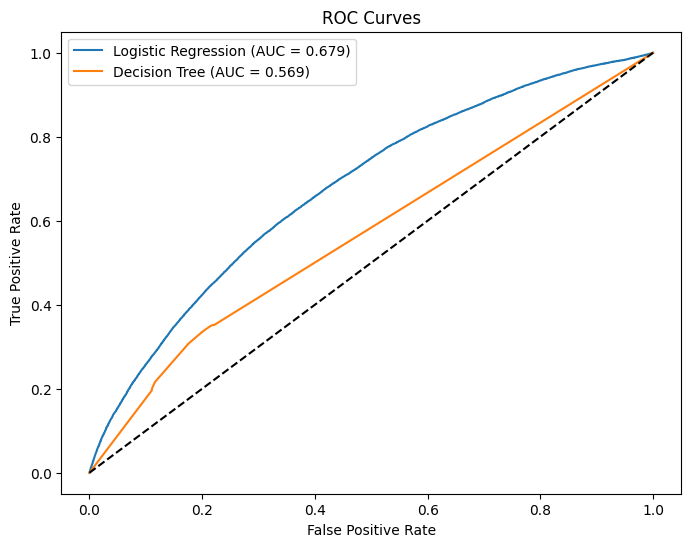

In [26]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
lst_auc = []

for name, model in models.items(): 
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:,1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        # fallback: just use predictions (not ideal for ROC, but works)
        y_score = model.predict(X_test)
        print(f"Warning: {name} does not have predict_proba or decision_function, using predict()")

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = auc(fpr, tpr)
    lst_auc.append((name, auc_score))

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")
    print(f"AUC of {name}: {auc_score:.3f}")

plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [ ]:
# Finally we are going to save the dataset cleaned
df_caract.to_csv("df_caract_clean.csv", index=False)

In [ ]:
df_caract = pandas.read_csv("df_caract_clean.csv")

In [ ]:
print("All columns:", df_caract.columns)
print("Features:", features)

All columns: Index(['Num_Acc', 'lum', 'agg', 'int', 'atm', 'col', 'geo_cluster', 'day_sin',
       'day_cos', 'hour_sin', 'hour_cos'],
      dtype='str')
Features: ['lum', 'agg', 'int', 'atm', 'col', 'geo_cluster', 'day_sin', 'day_cos', 'hour_sin', 'hour_cos']
